In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RepeatedStratifiedKFold

import matplotlib.pyplot as plt
plt.style.use('ggplot') # using stylesheet for Matplotlib and Seaborn style plots.

import seaborn as sns
import joblib


### Reading the dataset ###

In [2]:
# Read the dataset
df = pd.read_csv('../../data/Student Depression Dataset.csv')

In [3]:
# Display the dataset shape(rows,columns)
df.shape

(27901, 18)

In [4]:
# Display first 10 rows
df.head(10)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1


In [5]:
# Listdown columns
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [6]:
# list the columns types
df.dtypes

id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

In [7]:
# Detail description about numerical data 
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


### Data preperation ###

In [8]:
# Check missing values in each column
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [9]:
# drop the  3 rows with null values
df = df.dropna()

# Check again missing values in each column
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [10]:
df = df[df['Profession'] == 'Student']

In [11]:
# Drop unnecessary columns
cols_to_drop = ['id', 'Work Pressure', 'Job Satisfaction', 'City', 'Profession']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)
df.head()

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [12]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("?", "")
df.head()

,Gender,Age,Academic_Pressure,CGPA,Study_Satisfaction,Sleep_Duration,Dietary_Habits,Degree,Have_you_ever_had_suicidal_thoughts_,Work/Study_Hours,Financial_Stress,Family_History_of_Mental_Illness,Depression
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [13]:
df.rename(columns={'Have_you_ever_had_suicidal_thoughts_': 'Suicidal_Thoughts'}, inplace=True)
df.rename(columns={'Family_History_of_Mental_Illness': 'Mental_Illness_History'}, inplace=True)
df.rename(columns={'Work/Study_Hours': 'Study_Hours'}, inplace=True)
df.head()

,Gender,Age,Academic_Pressure,CGPA,Study_Satisfaction,Sleep_Duration,Dietary_Habits,Degree,Suicidal_Thoughts,Study_Hours,Financial_Stress,Mental_Illness_History,Depression
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [14]:
# Seperating columns into categorical and numerical 
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"categorical colums are : {categorical_cols}")
print(f"numarical colums are : {numerical_cols}")

categorical colums are : ['Gender', 'Sleep_Duration', 'Dietary_Habits', 'Degree', 'Suicidal_Thoughts', 'Mental_Illness_History']
numarical colums are : ['Age', 'Academic_Pressure', 'CGPA', 'Study_Satisfaction', 'Study_Hours', 'Financial_Stress', 'Depression']


In [15]:
#Group Age

# if 'Age' in df.columns and 'Age_Group' not in df.columns:
#     df['Age_Group'] = pd.cut(df['Age'],
#                              bins=[0, 18, 25, 35, 100],
#                              labels=['Teen', 'Young Adult', 'Adult', 'Senior']).astype(str)

In [16]:
 # Show unique values in categorical columns
for col in df.select_dtypes(include='object'):
    print(f"{col} : {df[col].nunique()}:\n {df[col].unique()}")

Gender : 2:
 ['Male' 'Female']
Sleep_Duration : 5:
 ['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others']
Dietary_Habits : 4:
 ['Healthy' 'Moderate' 'Unhealthy' 'Others']
Degree : 28:
 ['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'PhD' 'Class 12' 'B.Ed' 'LLB' 'BE'
 'M.Ed' 'MSc' 'BHM' 'M.Pharm' 'MCA' 'MA' 'B.Com' 'MD' 'MBA' 'MBBS' 'M.Com'
 'B.Arch' 'LLM' 'B.Tech' 'BBA' 'ME' 'MHM' 'Others']
Suicidal_Thoughts : 2:
 ['Yes' 'No']
Mental_Illness_History : 2:
 ['No' 'Yes']


In [17]:
# """"
# # Clean values in city column
# valid_cities = [
#     'visakhapatnam', 'bangalore', 'srinagar', 'varanasi', 'jaipur', 'pune', 'thane',
#     'chennai', 'nagpur', 'nashik', 'vadodara', 'kalyan', 'rajkot', 'ahmedabad',
#     'kolkata', 'mumbai', 'lucknow', 'indore', 'surat', 'ludhiana', 'bhopal',
#     'meerut', 'agra', 'ghaziabad', 'hyderabad', 'vasai-virar', 'kanpur', 'patna',
#     'faridabad', 'delhi'
# ]

# df['City'] = df['City'].str.lower().apply(lambda x: x if x in valid_cities else 'other')
# """

In [18]:
# check for duplicate rows 
print(df.duplicated().sum())

0


In [19]:
# check whether missing values after cleaning
print(df.isnull().sum())


Gender                    0
Age                       0
Academic_Pressure         0
CGPA                      0
Study_Satisfaction        0
Sleep_Duration            0
Dietary_Habits            0
Degree                    0
Suicidal_Thoughts         0
Study_Hours               0
Financial_Stress          0
Mental_Illness_History    0
Depression                0
dtype: int64


In [20]:
# drop the null value rows 
df = df.dropna()
# check whether missing values after cleaning and dropping
print(df.isnull().sum())

Gender                    0
Age                       0
Academic_Pressure         0
CGPA                      0
Study_Satisfaction        0
Sleep_Duration            0
Dietary_Habits            0
Degree                    0
Suicidal_Thoughts         0
Study_Hours               0
Financial_Stress          0
Mental_Illness_History    0
Depression                0
dtype: int64


### Freature Understanding ###

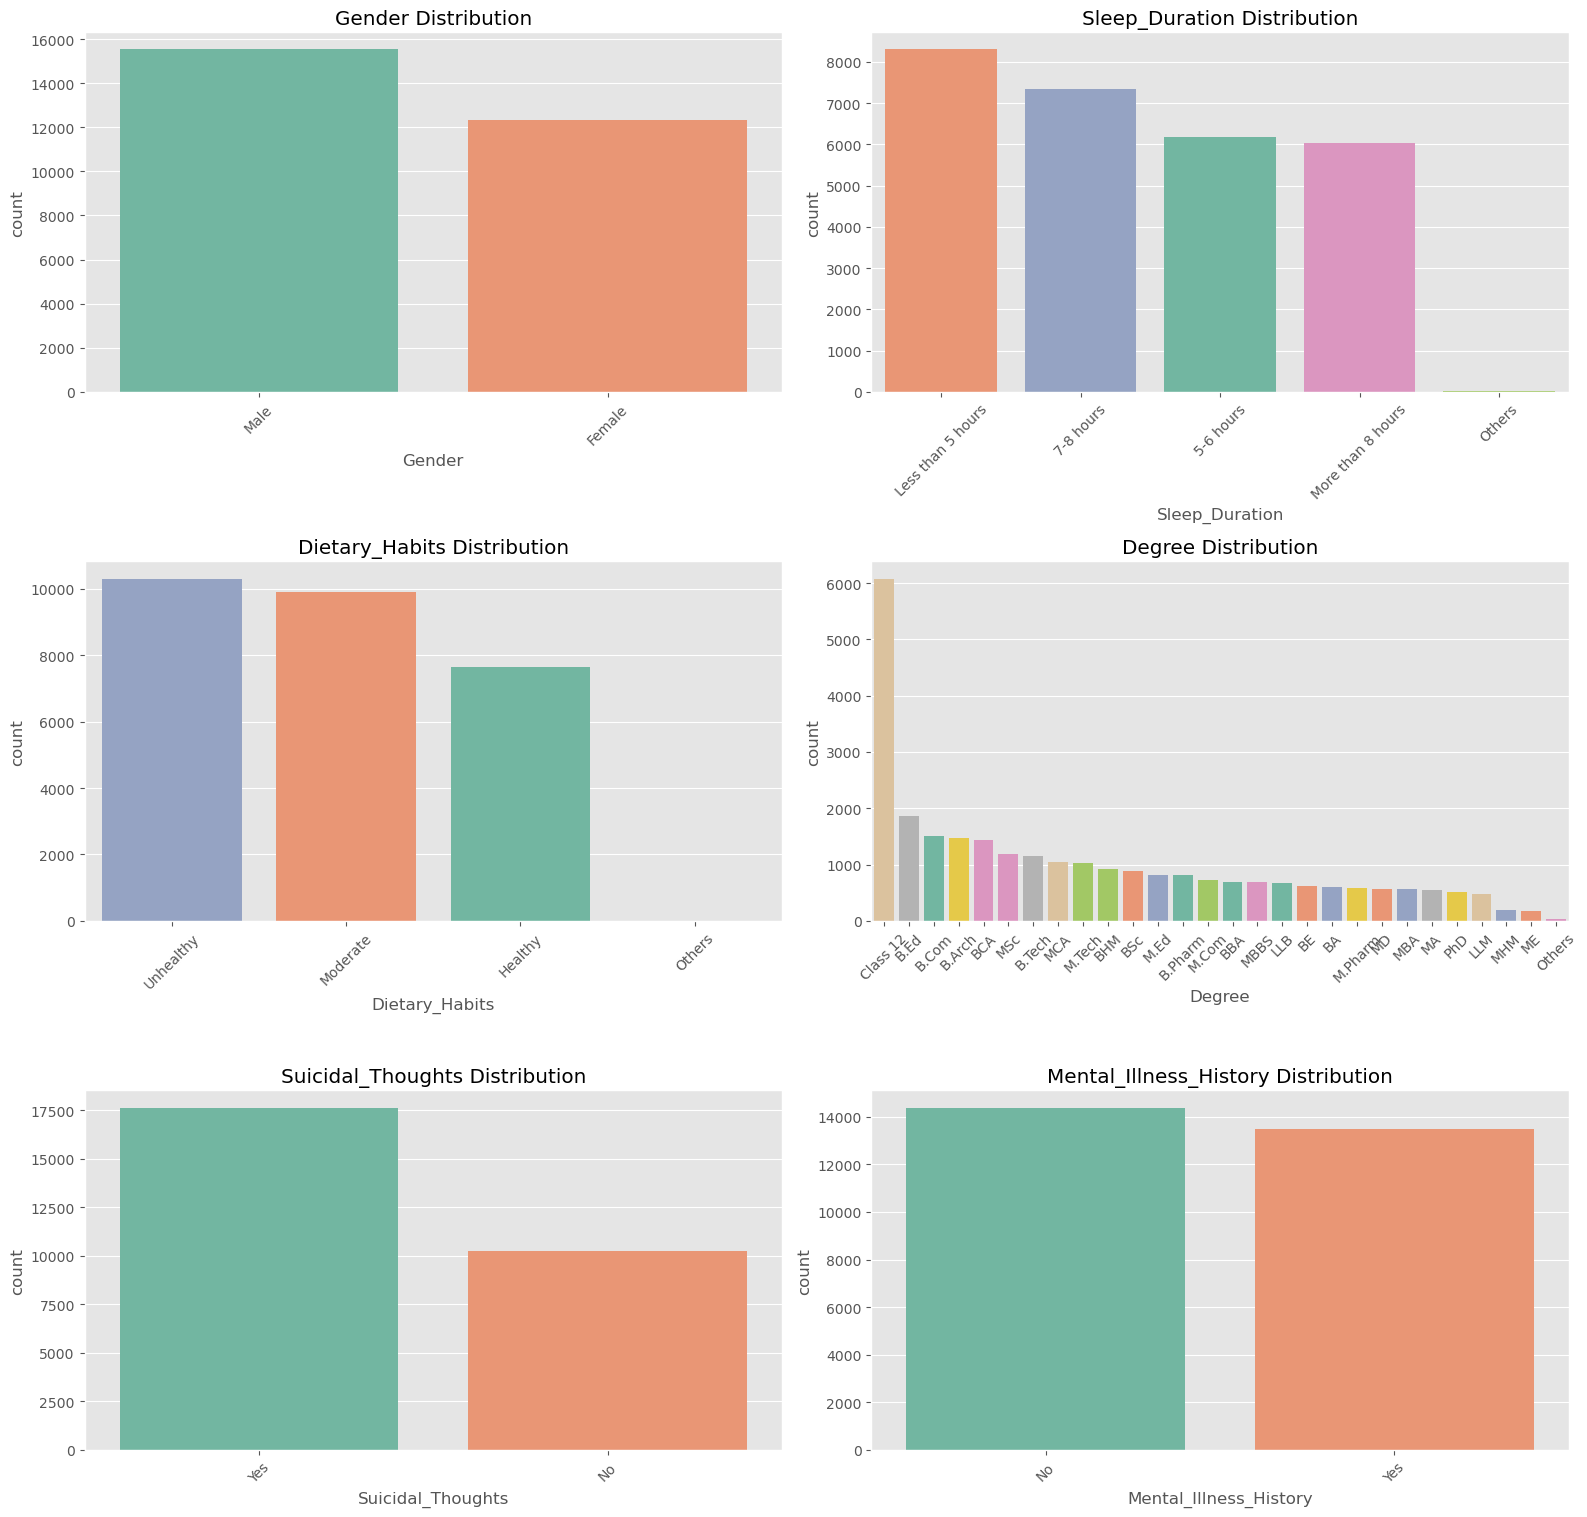

In [21]:

# Recreate categorical and numerical columns after renaming
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Plot Categorical Columns
plt.figure(figsize=(16, 20))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(data=df, x=col, hue=col, order=df[col].value_counts().index, palette='Set2')
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

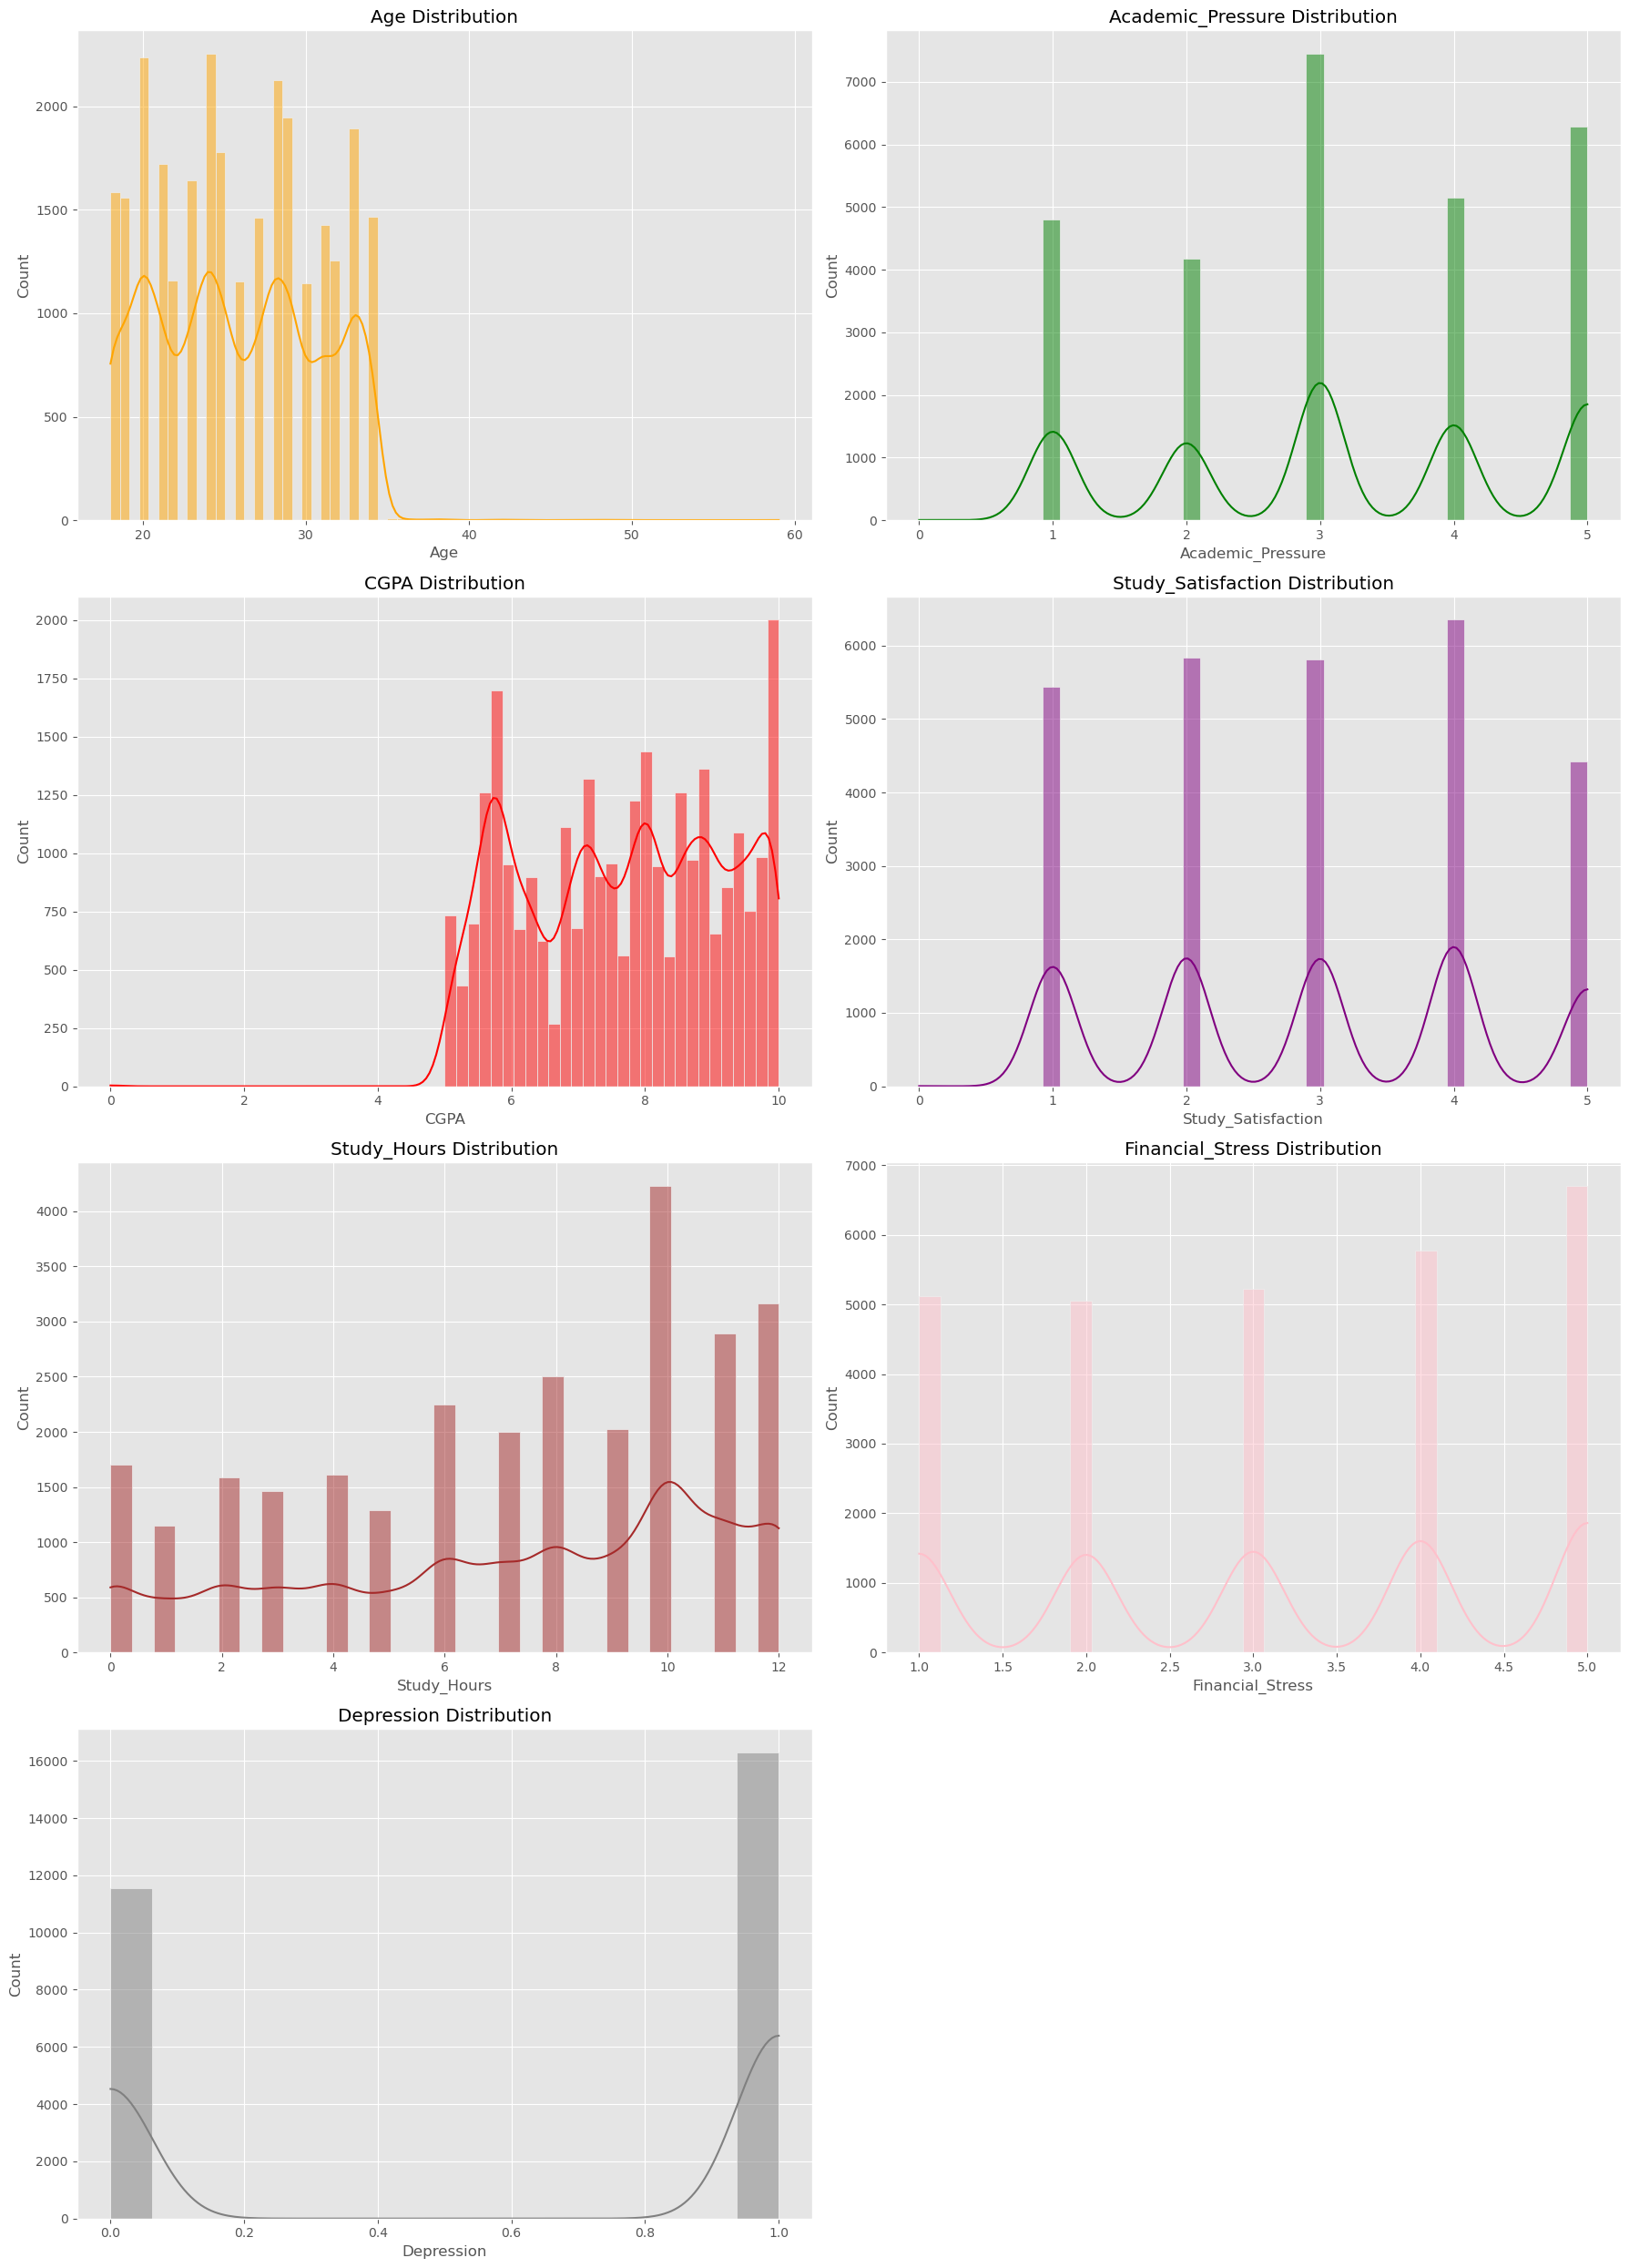

In [22]:
# Plot Numerical Columns
colour = ['skyblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
plt.figure(figsize=(18, 25))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, color=colour[i % len(colour)])
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

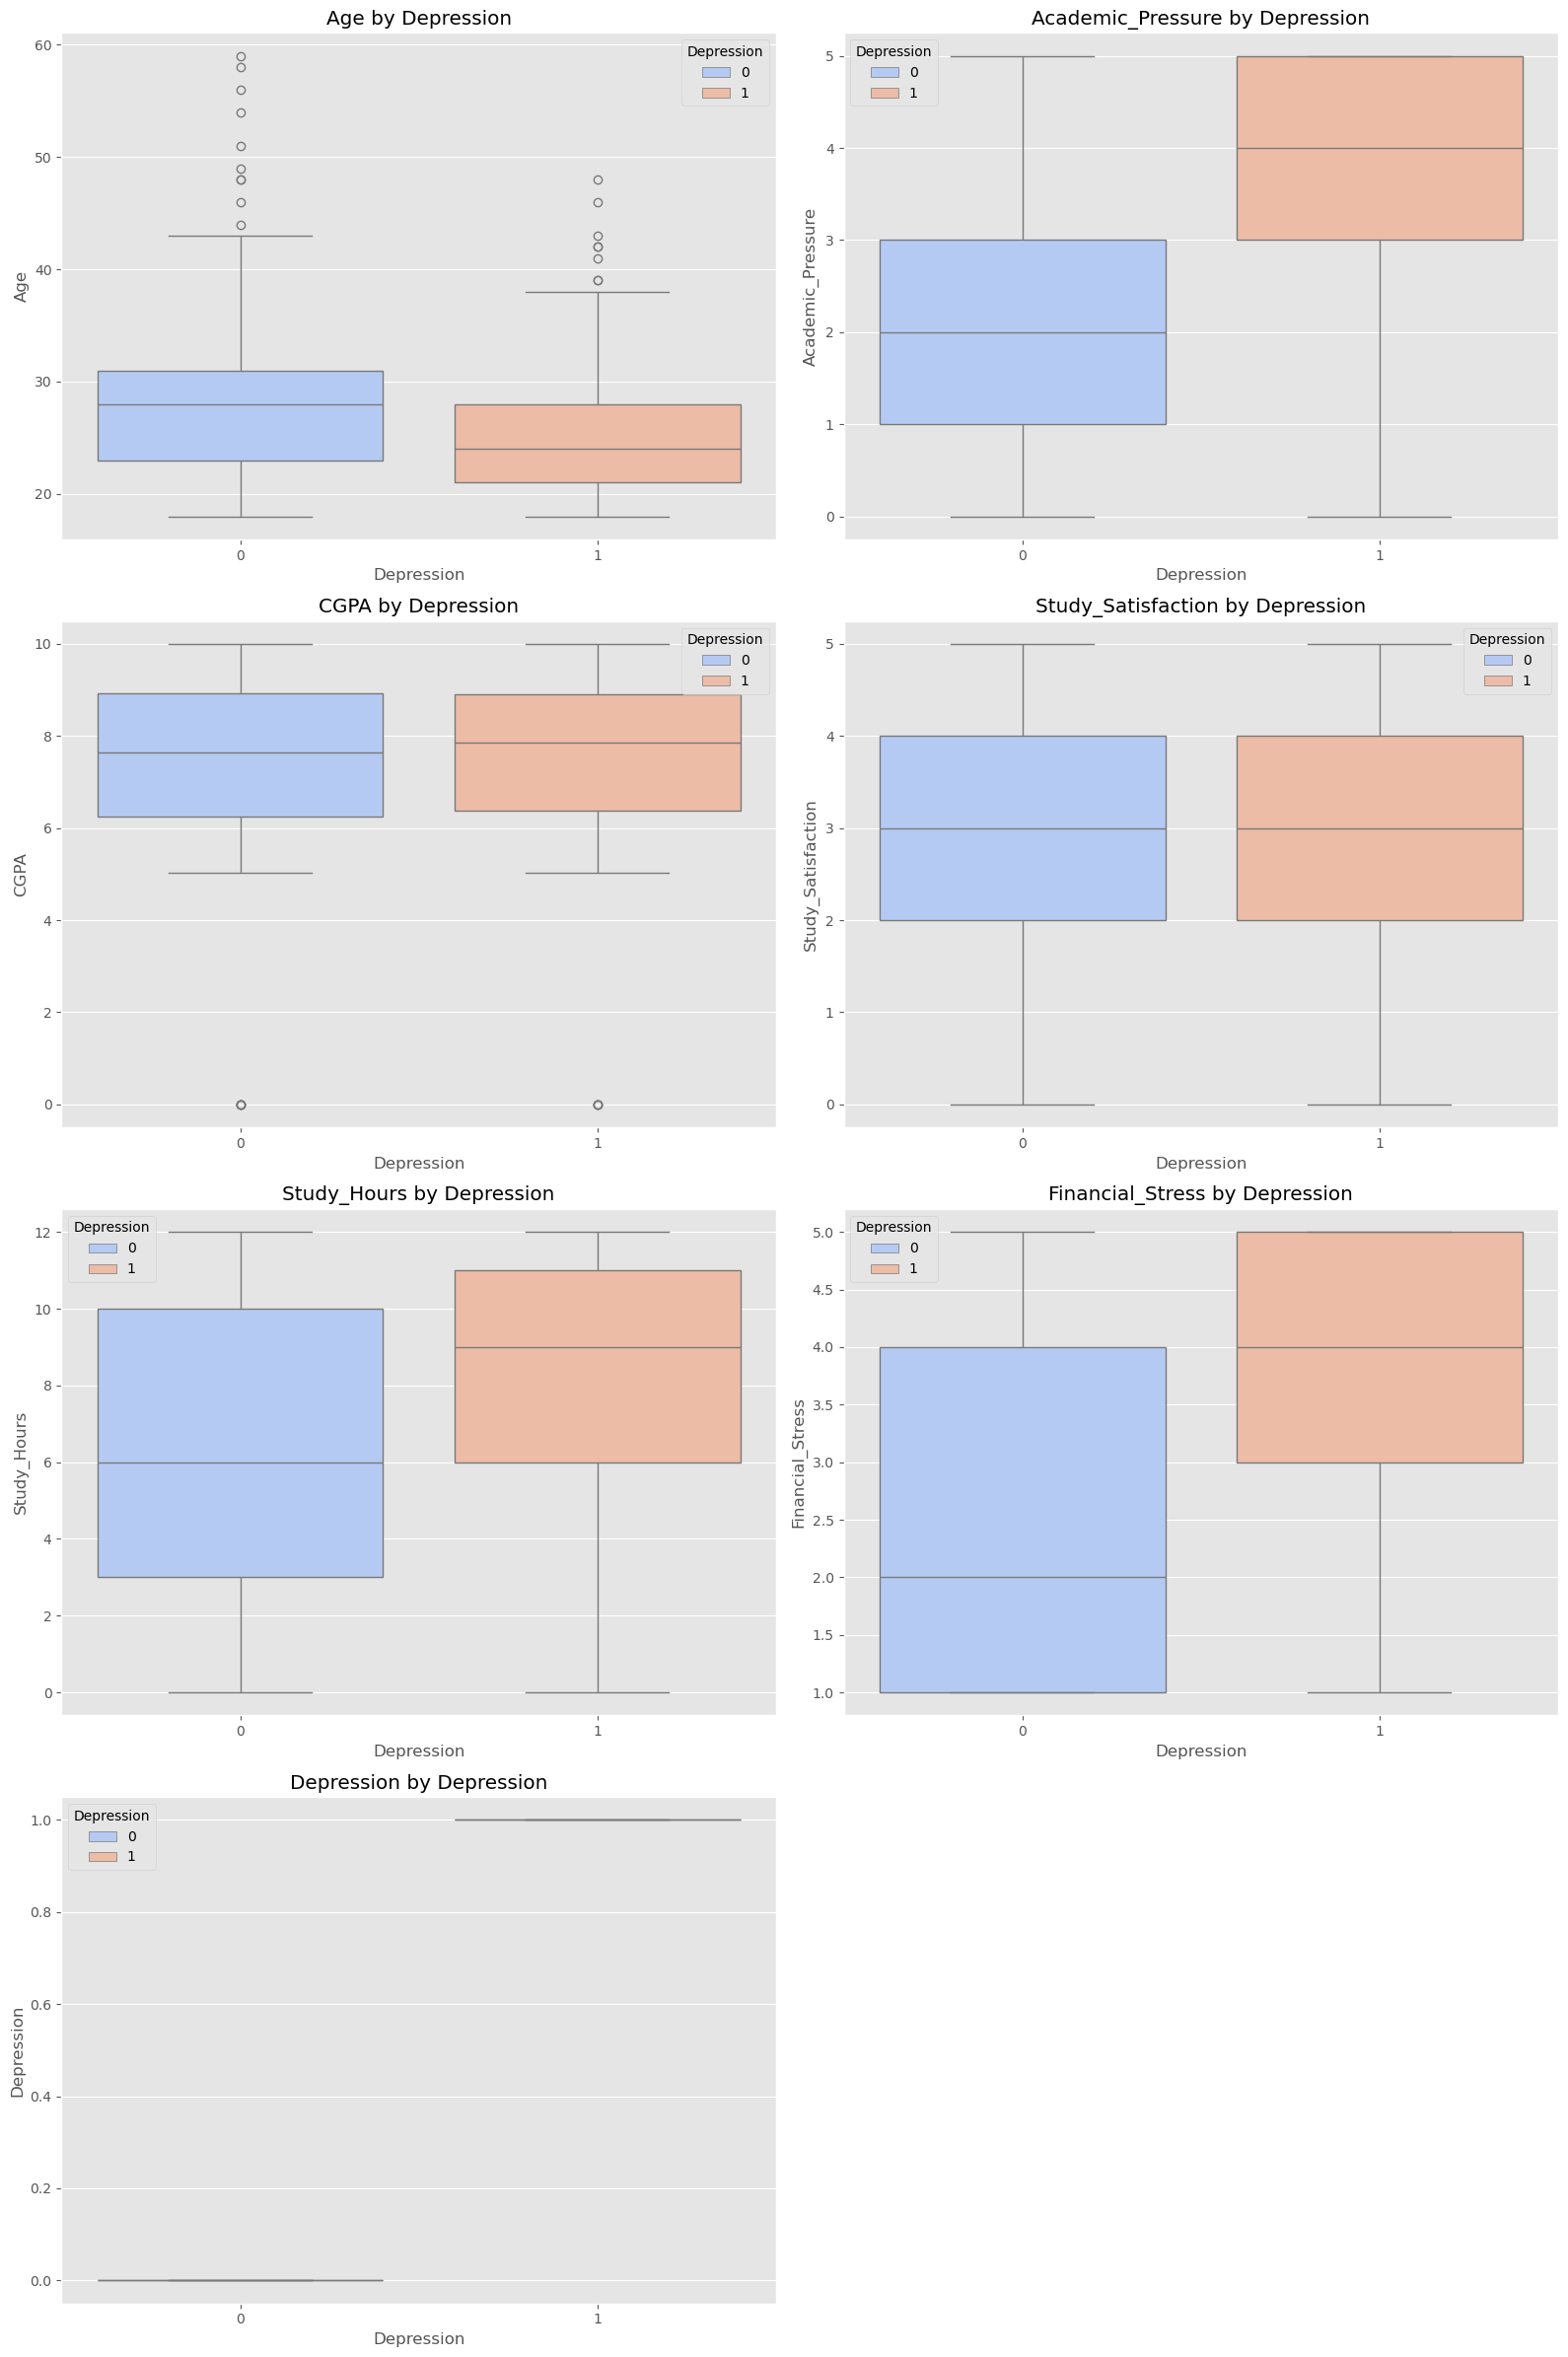

In [23]:
# Numerical vs Depression (Boxplots)
plt.figure(figsize=(16, 24))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=df, x='Depression', y=col, hue='Depression', palette='coolwarm')
    plt.title(f"{col} by Depression")
plt.tight_layout()
plt.show()

<Axes: xlabel='Age'>

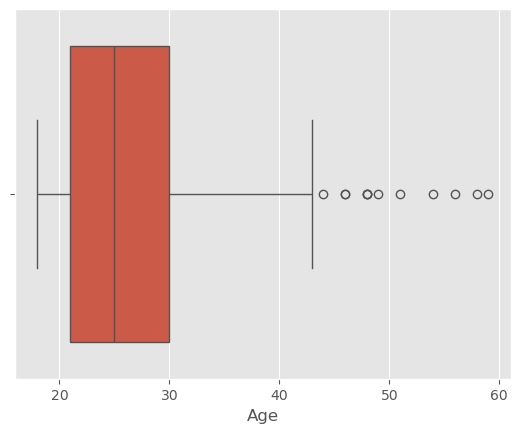

In [24]:

# checking outliers of age
sns.boxplot(x=df['Age'])

<Axes: xlabel='Age'>

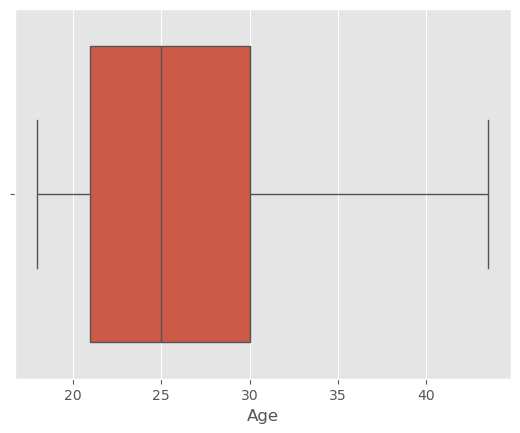

In [25]:
# Remove the outliers of age column using IQR method 

def remove_outliers_age(text):
    q1 = df['Age'].quantile(0.25)
    q3 = df['Age'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    if text > upper_bound:
        return upper_bound
    elif text < lower_bound:
        return lower_bound
    else:
        return text

df['Age'] = df['Age'].apply(remove_outliers_age)

# Checking outliers of age after removing outliers
sns.boxplot(x=df['Age'])

In [26]:

# # Encoding categorical variables using one-hot encoding(for SVM model)
# df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# # Show encoded columns
# print("Encoded columns:")
# print(df_encoded.columns)

# # Show data types to confirm all are now numeric
# print("\nData types after encoding:")
# print(df_encoded.dtypes.value_counts())

# # Confirm there are no object (text) columns left
# print("\nAny object (text) columns left?")
# print(df_encoded.select_dtypes(include='object').columns.tolist())

# # Display the first few rows of the encoded DataFrame
# print("\nEncoded DataFrame:")
# df_encoded.head()

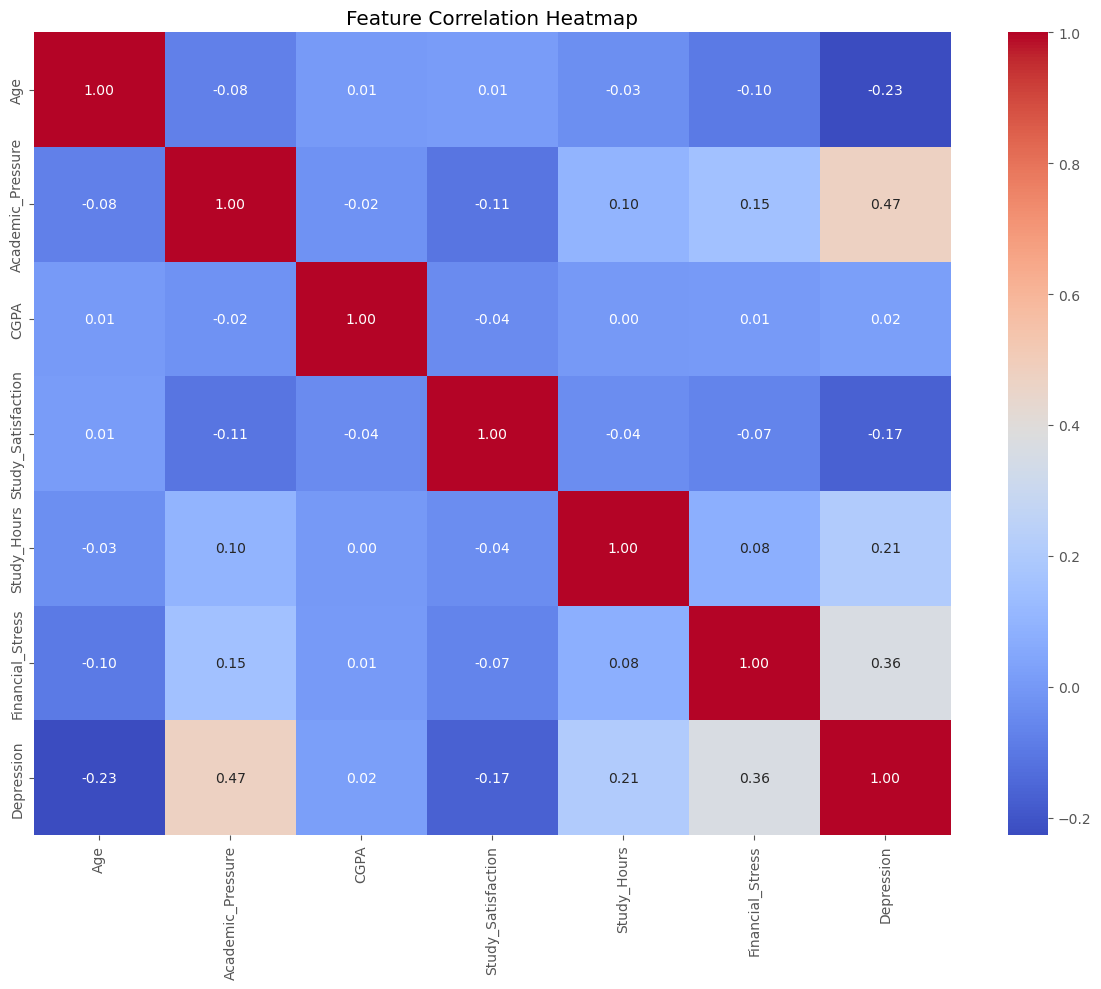

In [27]:
# Correlation Heatmap with the encoded DataFrame
plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Train the Model ###

In [28]:
# Spliting the dataset into features (X) and target (y)
X = df.drop("Depression", axis=1)
y = df["Depression"]

In [29]:
# Splitting the dataset into training 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [30]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [31]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

In [32]:
# Pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

In [33]:

# Training the SVM model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'Sleep_Duration',
                                                   'Dietary_Habits', 'Degree',
                                                   'Suicidal_Thoughts',
                                                   'Mental_Illness_History']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Academic_Pressure',
                                                   'CGPA', 'Study_Satisfaction',
                                                   'Study_Hours',
                                                   'Financial_Stress'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', SVC(probability=True, random_state=42))])

In [34]:
y_pred_def = pipeline.predict(X_test)
y_prob_def = pipeline.predict_proba(X_test)[:, 1]

In [35]:
print("\n================ DEFAULT SVM RESULTS ================")
print("Train Accuracy:", pipeline.score(X_train, y_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_def))
print("ROC AUC       :", roc_auc_score(y_test, y_prob_def))
print("\nClassification Report:\n", classification_report(y_test, y_pred_def))


================ DEFAULT SVM RESULTS ================
Train Accuracy: 0.8652153110047847
Test Accuracy : 0.8406774795464332
ROC AUC       : 0.9107779908050307

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81      2890
           1       0.87      0.86      0.86      4077

    accuracy                           0.84      6967
   macro avg       0.84      0.84      0.84      6967
weighted avg       0.84      0.84      0.84      6967



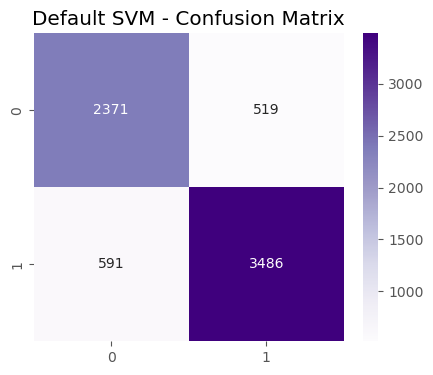

In [36]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_def), annot=True, fmt="d", cmap="Purples")
plt.title("Default SVM - Confusion Matrix")
plt.show()

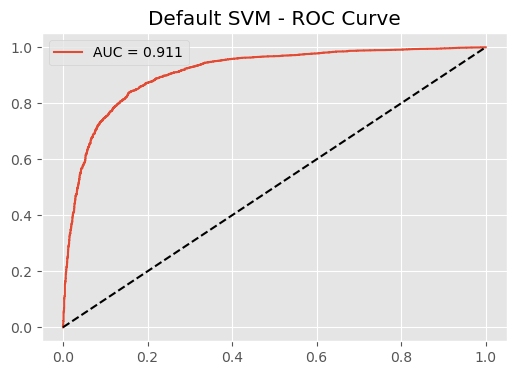

In [37]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_def)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, y_prob_def))
plt.plot([0,1],[0,1], 'k--')
plt.title("Default SVM - ROC Curve")
plt.legend()
plt.show()

In [40]:
# Hyperparameter Tuning using GridSearchCV
grid_params = {
    "model__C": [0.1, 0.5, 1, 2],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf"], 
}

grid_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(probability=True, random_state=42))
])


grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=grid_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)
 

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END model__C=0.5, model__gamma=scale, model__kernel=rbf; total time= 4.0min
[CV] END .model__C=0.5, model__gamma=auto, model__kernel=rbf; total time= 4.0min
[CV] END model__C=0.5, model__gamma=scale, model__kernel=rbf; total time= 4.0min
[CV] END model__C=0.5, model__gamma=scale, model__kernel=rbf; total time= 4.1min
[CV] END model__C=0.5, model__gamma=scale, model__kernel=rbf; total time= 4.1min
[CV] END model__C=0.5, model__gamma=scale, model__kernel=rbf; total time= 4.2min
[CV] END .model__C=0.1, model__gamma=auto, model__kernel=rbf; total time= 4.2min
[CV] END model__C=0.1, model__gamma=scale, model__kernel=rbf; total time= 4.2min
[CV] END .model__C=0.1, model__gamma=auto, model__kernel=rbf; total time= 4.3min
[CV] END .model__C=0.1, model__gamma=auto, model__kernel=rbf; total time= 4.4min
[CV] END model__C=0.1, model__gamma=scale, model__kernel=rbf; total time= 4.4min
[CV] END .model__C=0.1, model__gamma=auto, model_

In [41]:
y_pred_grid = best_svm.predict(X_test)
y_prob_grid = best_svm.predict_proba(X_test)[:, 1]

print("\n================ GRID SEARCH SVM RESULTS ================")
print("Train Accuracy:", best_svm.score(X_train, y_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_grid))
print("ROC AUC       :", roc_auc_score(y_test, y_prob_grid))
print("\nClassification Report:\n", classification_report(y_test, y_pred_grid))


================ GRID SEARCH SVM RESULTS ================
Train Accuracy: 0.8482775119617225
Test Accuracy : 0.8413951485574853
ROC AUC       : 0.9198873247087

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81      2890
           1       0.88      0.85      0.86      4077

    accuracy                           0.84      6967
   macro avg       0.84      0.84      0.84      6967
weighted avg       0.84      0.84      0.84      6967



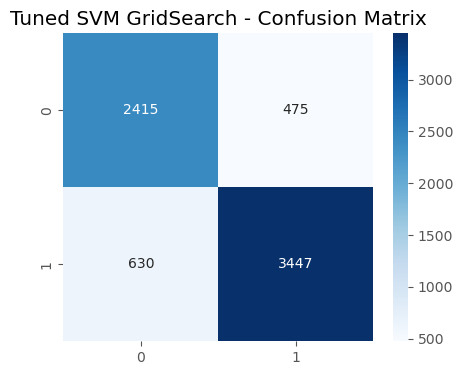

In [42]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_grid), annot=True, fmt="d", cmap="Blues")
plt.title("Tuned SVM GridSearch - Confusion Matrix")
plt.show()

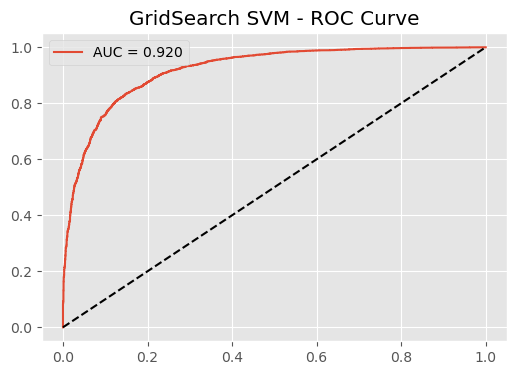

In [43]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_grid)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, y_prob_grid))
plt.plot([0,1],[0,1], 'k--')
plt.title("GridSearch SVM - ROC Curve")
plt.legend()
plt.show()

In [ ]:
# # Hyperparameter Tuning using RandomizedSearchCV
# from sklearn.model_selection import RandomizedSearchCV

# # Define the parameter grid
# param_dist = {
#     'C': [0.1, 1, 10, 100],
#     'gamma': ['scale', 'auto'],
#     'kernel': ['linear', 'rbf', 'poly']
# }

# # Create a RandomizedSearchCV object
# random_search = RandomizedSearchCV(svm_model, param_distributions=param_dist, n_iter=10, cv=3, verbose=2, random_state=42)

# # Fit the model
# random_search.fit(X_train, y_train)

# # Get the best parameters
# best_params = random_search.best_params_    

In [ ]:
# print("Best Parameters from RandomizedSearchCV:", best_params)
# print("Best Cross-Validation Score from RandomizedSearchCV:", random_search.best_score_)

In [44]:
# Save the best model
import joblib

joblib.dump(best_svm, 'best_svm_model.joblib')


['best_svm_model.joblib']